### Set Up

In [19]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce

In [20]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "cheung_variants" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "cheung_variants"

print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

filename_template = "%s_%d_choice_1.json"


scenarios_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [21]:
#get all of the json files in the annotated_output_path
json_files = list(annotated_output_path.glob("*bird*.json"))

### Define Functions

In [22]:
#parse the read in filenames to get the condition and id
def parse_filename(filename):
    #filename is of the form "%s_%d_choice_1.json"
    parts = filename.stem.split("_")
    narrative = parts[0]
    id = int(parts[1])
    return narrative, id

In [23]:
def read_scenario(file_path): 

    narrative, id = parse_filename(file_path)


    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]


    # also return original scenario text for reference
    with open(scenarios_path / f"{narrative}.json") as f:
        scenario_list = json.load(f)
        #get the one with the matching id
        this_sceneraio = next(s for s in scenario_list if s['id'] == id)


         #extract the condition from the json read in
        scenario_text = this_sceneraio['text']
        scenario_deontology = this_sceneraio['deontology_level']
        scenario_utility = this_sceneraio['utility_level']
        
    #create a little dictionary with everything in it
    scenario_info = {
        "narrative": narrative,
        "id": id,
        "text": scenario_text,
        "deontology": scenario_deontology,
        "utility": scenario_utility
    }

    return nodes, scenario_info

In [24]:

def events_to_utility_df(nodes):
  
    util_dfs = []

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'event':
            links = node.get('links')
            data = {}
            for link in links:
                to_node = link.get('to_node')
                value = link.get('link', {}).get('value')
                data[to_node] = value
                label = n.get('label')
                df = pd.DataFrame([data], index=[label])
            util_dfs.append(df)

    df = pd.concat(util_dfs, ignore_index=False)
    df = df.apply(pd.to_numeric)
    
    return df


In [25]:
def extract_deontology(nodes):
    
    value = None

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'action_choice':
            # print(n.get('label'))
            links = node.get('links')
            # print(links)
            for link in links:
                    # print(link)
                    if link.get('link', {}).get('kind')=='v-link':
                        value = link.get('link', {}).get('value')
    

    return value

In [26]:
#attempt for a generitc utility function to read the annotation files for a given annotation output json file.
def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line to create a list of JSON objects
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the first being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = b_link_value
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }
    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

In [27]:
def get_utilities(nodes):
    util_df =  events_to_utility_df(nodes)


    # For each being (column), calculate product of positive and negative utilities across outcomes
    utility_products = {}
    for col in util_df.columns:
        positive_utils = util_df[col][util_df[col] > 0]
        negative_utils = util_df[col][util_df[col] < 0]
        pos_product = reduce(lambda x, y: x * y, positive_utils, 1) if not positive_utils.empty else 0
        neg_product = reduce(lambda x, y: x * y, negative_utils, 1) if not negative_utils.empty else 0
        utility_products[col] = {"positive_product": pos_product, "negative_product": neg_product, "difference": pos_product - neg_product}

        util_mean_df = pd.DataFrame({'mean_utility': util_df.mean()})
    
    return np.mean(util_mean_df)


### Create dataframe with utility and deontology

In [28]:
rows = []

for file_path in json_files:
    nodes, scenario_dictionary = read_scenario(file_path)

    utility_rated = get_utilities(nodes)

    if hasattr(utility_rated, "item"):
        try:
            utility_rated = utility_rated.item()
        except Exception:
            pass

    rows.append(
        {
            "scenario_id": scenario_dictionary.get("id"),
            "narrative": scenario_dictionary.get("narrative"),
            "deontology_label": scenario_dictionary.get("deontology"),
            "utility_label": scenario_dictionary.get("utility"),
            "deontology_rating": extract_deontology(nodes),
            "utility_rating": utility_rated,
        }
    )

results_df = pd.DataFrame(rows)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_rating
0,3,bird,3,3,-25.0,-78.500000
1,2,bird,2,3,-32.0,-46.000000
2,6,bird,3,2,-44.0,-17.000000
3,1,bird,1,3,-53.0,-59.583333
4,5,bird,2,2,-32.0,-48.750000
5,4,bird,1,2,-25.0,-73.500000
6,4,bird,1,2,-53.0,-51.000000
7,1,bird,1,3,-25.0,-80.000000
8,5,bird,2,2,-25.0,-70.833333
9,2,bird,2,3,-25.0,-78.500000


In [ ]:
# Ensure numeric columns are numeric
results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
results_df["utility_rating"] = pd.to_numeric(results_df["utility_rating"], errors="coerce")

# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


(  deontology_label  n  deontology_rating_mean  deontology_rating_se  \
 0                1  4                   -39.0              8.082904   
 1                2  4                   -28.5              2.020726   
 2                3  4                   -34.5              5.484828   
 
    utility_rating_mean  utility_rating_se  
 0           -66.020833           6.572809  
 1           -61.020833           8.051942  
 2           -43.500000          20.503049  ,
   utility_label  n  deontology_rating_mean  deontology_rating_se  \
 0             2  6                   -34.0              4.857983   
 1             3  6                   -34.0              4.857983   
 
    utility_rating_mean  utility_rating_se  
 0           -56.597222           9.361179  
 1           -57.097222          12.688731  )

In [30]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,4,-39.0,8.082904,-66.020833,6.572809
1,2,4,-28.5,2.020726,-61.020833,8.051942
2,3,4,-34.5,5.484828,-43.500000,20.503049


In [32]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,2,6,-34.0,4.857983,-56.597222,9.361179
1,3,6,-34.0,4.857983,-57.097222,12.688731


In [33]:

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_rating"],
    var_name="measure",
    value_name="value",
)


In [34]:
plot_df

,deontology_label,utility_label,measure,value
0,3,3,deontology_rating,-25.000000
1,2,3,deontology_rating,-32.000000
2,3,2,deontology_rating,-44.000000
3,1,3,deontology_rating,-53.000000
4,2,2,deontology_rating,-32.000000
5,1,2,deontology_rating,-25.000000
6,1,2,deontology_rating,-53.000000
7,1,3,deontology_rating,-25.000000
8,2,2,deontology_rating,-25.000000
9,2,3,deontology_rating,-25.000000


In [35]:
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)

# Re-run the plotting cell after this cell

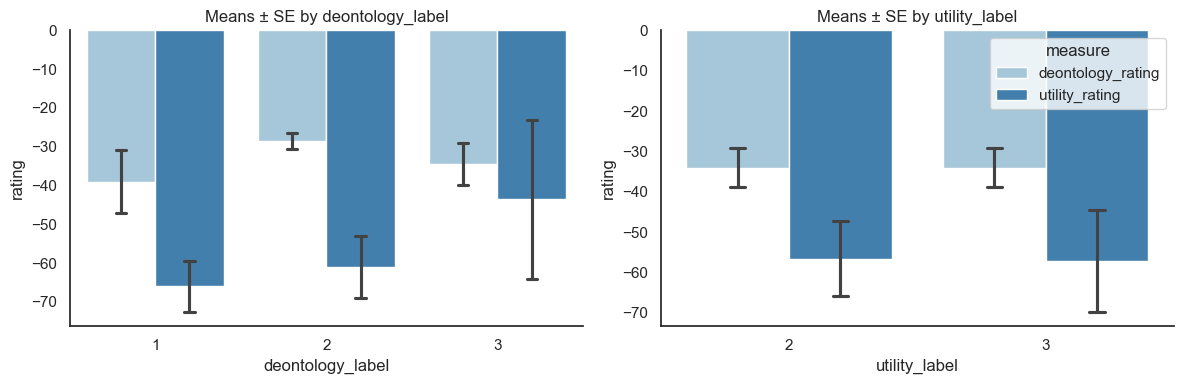

In [37]:
# Two blue shades for the two measures
blue_palette = {
    "deontology_rating": "#9ecae1",  # lighter blue
    "utility_rating": "#3182bd",     # darker blue
}

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

sns.barplot(
    data=plot_df,
    x="deontology_label",
    y="value",
    hue="measure",
    estimator="mean",
    errorbar="se",
    capsize=0.12,
    palette=blue_palette,
    ax=axes[0],
)
axes[0].set_title("Means ± SE by deontology_label")
axes[0].set_xlabel("deontology_label")
axes[0].set_ylabel("rating")
axes[0].grid(False)

sns.barplot(
    data=plot_df,
    x="utility_label",
    y="value",
    hue="measure",
    estimator="mean",
    errorbar="se",
    capsize=0.12,
    palette=blue_palette,
    ax=axes[1],
)
axes[1].set_title("Means ± SE by utility_label")
axes[1].set_xlabel("utility_label")
axes[1].set_ylabel("rating")
axes[1].grid(False)

if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title="measure", loc="best")

sns.despine()
plt.tight_layout()
plt.show()